# 📚 Section 2. Matplotlib Basic Structure
> 섹션 2. Matplotlib 기초 구조

---
# 🎯 Learning Objective · 학습 목표
Today I want to learn: · 오늘 배우고 싶은 것:
- [x] Understand the difference between a Figure and an Axes, and why Axes is not the same as Axis  
Figure와 Axes의 차이, 그리고 Axes가 Axis와 다른 이유 이해하기
- [x] Use plt.subplots() to build single, 1x2, and 2x2 chart layouts, and apply the 10 most-used Axes settings  
plt.subplots()로 단일·1x2·2x2 레이아웃을 만들고, 가장 많이 쓰는 10가지 Axes 설정 적용하기
- [x] Set up a Korean font correctly and save a finished chart with plt.savefig() the right way  
한글 폰트를 올바르게 설정하고 plt.savefig()로 완성된 차트를 제대로 저장하기

---
# 🧠 Concept · 개념

## What is it? · 무엇인가?

The first two objects you need to understand in Matplotlib are **Figure** and **Axes**. A Figure is the entire canvas or window — it owns the overall size (`figsize`), margins, and an overall title (`suptitle`). An Axes is a single plot area *inside* that Figure — it owns its own x-axis, y-axis, title, legend, and tick marks. A Figure can contain one or more Axes; when it contains several, we call that a "subplot," which Section 9 covers in depth.

Matplotlib에서 가장 먼저 이해해야 할 두 객체는 **Figure**와 **Axes**입니다. Figure는 그림 전체를 담는 도화지 또는 창(window) 그 자체이며, 크기(`figsize`), 여백, 전체 제목(`suptitle`)을 가집니다. Axes는 Figure 안에 있는 실제 그래프 영역 하나이며, x축·y축·제목·범례·눈금을 가집니다. 하나의 Figure 안에는 하나 이상의 Axes가 들어갈 수 있고, Axes가 여러 개면 "서브플롯"이라 부르며 섹션 9에서 자세히 다룹니다.

⚠️ **The most common confusion:** "Axes" (looks plural, but it's the name of a single object) is a different word from "Axis" (the x-axis or y-axis line itself). Axis is the axis line; Axes is "one plot area," and that Axes contains an x-axis and a y-axis inside it.

⚠️ **가장 흔한 착각:** Axes(에이시즈, 복수형처럼 생겼지만 그 자체로 하나의 객체 이름)는 Axis(축, x축/y축)와 다른 단어입니다. Axis는 축 그 자체를, Axes는 "그래프가 그려지는 영역 하나"를 의미하며, 그 Axes 안에 x축과 y축이 포함되어 있는 구조입니다.

**Text anatomy diagram / 텍스트 해부도:**

```
┌─ FIGURE (fig) ────────────────────────────────┐
│  the whole canvas: figsize, suptitle live here │
│  전체 도화지 한 장. figsize, suptitle 소속       │
│                                                 │
│   ┌─ AXES (ax) ─────────────────────────────┐  │
│   │  one actual plot area / 그래프 영역 1개    │  │
│   │                                          │  │
│   │       title (ax.set_title)               │  │
│   │                                          │  │
│   │   data drawn here / 실제 데이터가 그려짐   │  │
│   │   (ax.plot / ax.bar / ax.scatter ...)    │  │
│   │                                          │  │
│   │   xlabel               legend            │  │
│   │   (ax.set_xlabel)      (ax.legend)       │  │
│   └──────────────────────────────────────────┘  │
└─────────────────────────────────────────────────┘
```

## Why do we use it? · 왜 사용하는가?

Calling `plt.plot()` directly (without explicitly creating `fig, ax`) works fine for a single quick chart, but it breaks down the moment you need more than one chart in the same image — and in real DA/BA work, a report almost always needs several charts side by side. Explicitly holding onto the `ax` object is what lets you address *exactly* which plot area you're drawing into, customizing it, or saving it.

`fig, ax`를 명시적으로 만들지 않고 `plt.plot()`을 바로 호출해도 차트 하나를 빠르게 그릴 땐 문제가 없지만, 같은 이미지 안에 차트가 두 개 이상 필요해지는 순간 한계에 부딪힙니다 — 그리고 실제 DA/BA 업무에서 보고서는 거의 항상 여러 차트를 나란히 필요로 합니다. `ax` 객체를 명시적으로 붙잡고 있어야 정확히 어느 그래프 영역에 그리고 있는지 지정하고, 꾸미고, 저장할 수 있습니다.

## When is it used in Business Analytics? · 언제 비즈니스 분석에서 사용되는가?

Every single chart type covered in the rest of this course — Line, Bar, Histogram, Scatter, Pie, Heatmap, and every dashboard — is built starting from the exact same `fig, ax = plt.subplots()` pattern taught in this section. This is the shared engine, so getting comfortable with the 5 building blocks below pays off in every later section.

이후 이 강의에서 다루는 모든 차트 유형 — Line, Bar, Histogram, Scatter, Pie, Heatmap, 그리고 모든 대시보드 — 은 전부 이 섹션에서 배우는 `fig, ax = plt.subplots()` 패턴에서 시작합니다. 이것은 모든 차트가 공유하는 엔진이므로, 아래 5가지 구성요소에 익숙해지면 이후 모든 섹션에서 그 효과를 봅니다.

| Component / 구성 요소 | Meaning / 의미 | Related code / 관련 코드 |
|---|---|---|
| Figure | The whole canvas / 전체 도화지(캔버스) | `fig = plt.figure()` or `fig, ax = plt.subplots()` |
| Axes | One plot area, different from "axis" / 실제 그래프 영역, "axis(축)"과는 다른 개념 | `ax.plot()`, `ax.bar()`, etc. |
| Title | The Axes' title / Axes의 제목 | `ax.set_title()` |
| xlabel / ylabel | X-axis / Y-axis names / X축 / Y축 이름 | `ax.set_xlabel()`, `ax.set_ylabel()` |
| Legend | The legend box / 범례 | `ax.legend()` |

---
# 📝 Syntax · 문법

## Basic Syntax · 기본 문법

The standard opening pattern for almost every chart in this course: import, create `fig` and `ax` together with `plt.subplots()`, draw on `ax`, label it, then `plt.show()`.

이 강의의 거의 모든 차트에서 쓰이는 표준 시작 패턴입니다: import 후 `plt.subplots()`로 `fig`와 `ax`를 함께 만들고, `ax` 위에 그린 뒤 라벨을 달고 `plt.show()`로 표시합니다.

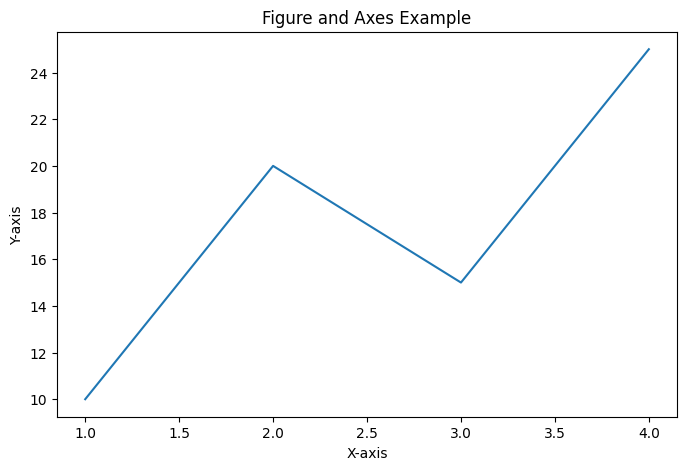

In [1]:
# Basic Syntax: create a Figure + one Axes, draw, label, show
# 기본 문법: Figure + Axes 하나를 만들고, 그리고, 라벨을 달고, 표시하기

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([1, 2, 3, 4], [10, 20, 15, 25])
ax.set_title("Figure and Axes Example")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
plt.show()

## Common Variations · 주요 변형

`plt.subplots(nrows, ncols)` is the single most-used function in real work — it creates a Figure and all of its Axes at once. Leave `nrows`/`ncols` out and you get one Axes back directly (not an array). Pass `(1, 2)` and `axes` becomes a 1-D array you index like `axes[0]`. Pass `(2, 2)` and `axes` becomes a 2-D array you index like `axes[0, 0]`.

`plt.subplots(nrows, ncols)`는 실무에서 가장 많이 쓰이는 함수입니다 — Figure 하나와 그 안의 모든 Axes를 한 번에 생성합니다. `nrows`/`ncols`를 생략하면 배열이 아니라 Axes 객체 하나가 그대로 반환됩니다. `(1, 2)`를 넘기면 `axes`는 `axes[0]`처럼 인덱싱하는 1차원 배열이 됩니다. `(2, 2)`를 넘기면 `axes`는 `axes[0, 0]`처럼 인덱싱하는 2차원 배열이 됩니다.

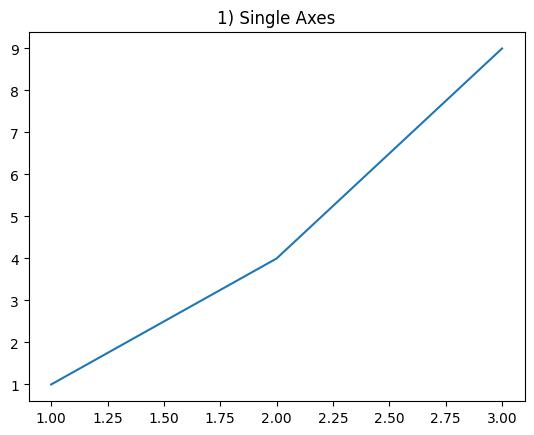

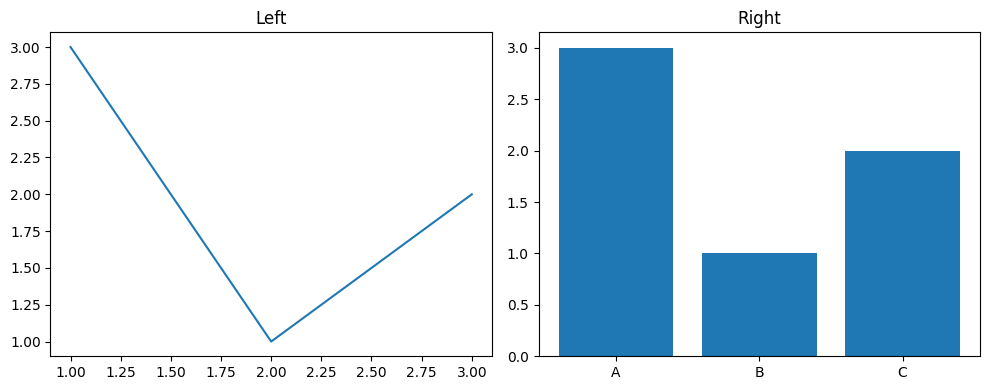

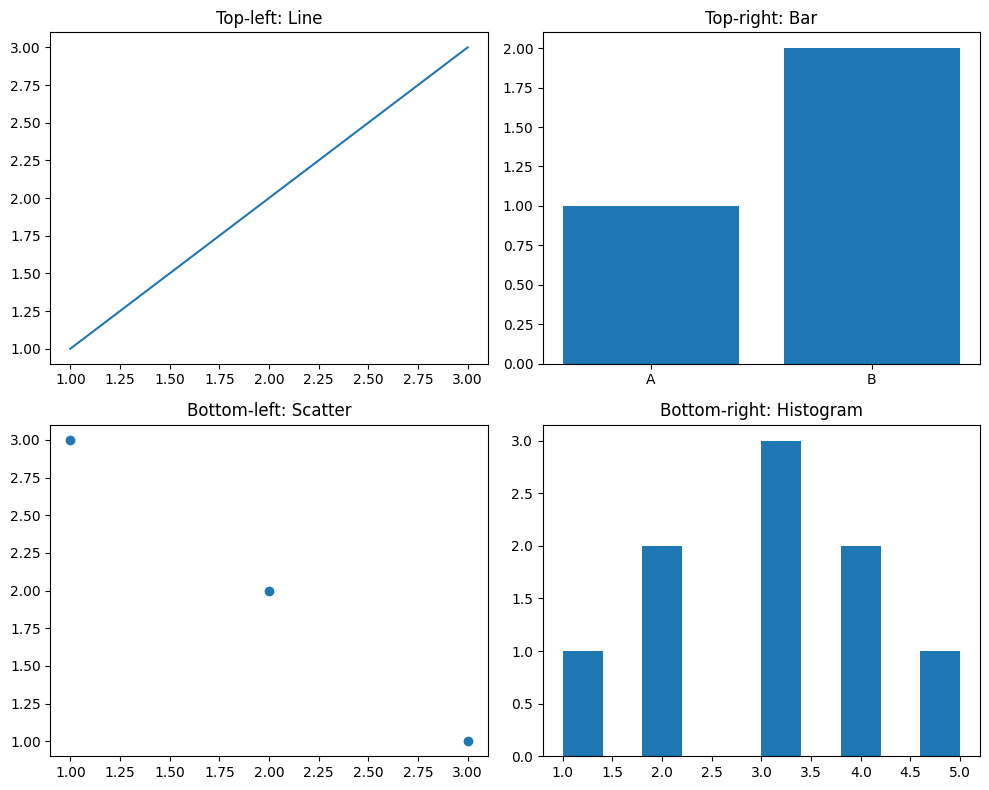

In [2]:
# Common Variations: single Axes vs 1x2 layout vs 2x2 grid
# 주요 변형: 단일 Axes vs 1x2 레이아웃 vs 2x2 격자

import matplotlib.pyplot as plt

# 1) Single Axes - nrows/ncols omitted -> defaults to (1, 1), ax is a single object
# 1) 단일 Axes - nrows/ncols 생략 시 기본값 (1, 1), ax는 배열이 아닌 객체 하나
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [1, 4, 9])
ax.set_title("1) Single Axes")
plt.show()

# 2) 1x2 layout - axes is a 1-D array of length 2: axes[0], axes[1]
# 2) 1x2 레이아웃 - axes는 길이 2인 1차원 배열: axes[0], axes[1]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot([1, 2, 3], [3, 1, 2])
axes[0].set_title("Left")
axes[1].bar(['A', 'B', 'C'], [3, 1, 2])
axes[1].set_title("Right")
plt.tight_layout()
plt.show()

# 3) 2x2 grid - axes is a 2-D array: axes[row, col]
# 3) 2x2 격자 - axes는 2차원 배열: axes[행, 열]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].plot([1, 2, 3], [1, 2, 3])
axes[0, 0].set_title("Top-left: Line")
axes[0, 1].bar(['A', 'B'], [1, 2])
axes[0, 1].set_title("Top-right: Bar")
axes[1, 0].scatter([1, 2, 3], [3, 2, 1])
axes[1, 0].set_title("Bottom-left: Scatter")
axes[1, 1].hist([1, 2, 2, 3, 3, 3, 4, 4, 5])
axes[1, 1].set_title("Bottom-right: Histogram")
plt.tight_layout()
plt.show()

---
# 🧪 Small Examples · 예제

## Example 1: The 10 Core Axes Settings · 예제 1: 핵심 Axes 설정 10가지

These are the 10 settings you'll reach for constantly when polishing any Axes:

Axes를 꾸밀 때 실무에서 가장 자주 쓰는 설정 10가지입니다:

| # | Setting / 설정 | Code / 코드 | Meaning / 의미 |
|---|---|---|---|
| 1 | title | `ax.set_title("...")` | Axes title / Axes 제목 |
| 2 | xlabel | `ax.set_xlabel("...")` | X-axis name / X축 이름 |
| 3 | ylabel | `ax.set_ylabel("...")` | Y-axis name / Y축 이름 |
| 4 | legend | `ax.legend(loc='upper left')` | Legend, needs `label=` in the plot call / 범례 (plot에 label= 필요) |
| 5 | grid | `ax.grid(True, alpha=0.3)` | Gridlines / 격자선 |
| 6 | figsize | `plt.subplots(figsize=(9,5.5))` | Figure size in inches / Figure 크기 (인치) |
| 7 | xlim / ylim | `ax.set_xlim(0,6)` / `ax.set_ylim(0,35)` | Axis display range / 축 표시 범위 |
| 8 | xticks | `ax.set_xticks([1,2,3])` | Tick positions & labels / 눈금 위치·이름 지정 |
| 9 | annotate | `ax.annotate(...)` | Arrow + text callout on a point / 특정 지점에 화살표+텍스트 주석 |
| 10 | tight_layout | `plt.tight_layout()` | Auto-fixes overlapping elements / 요소 겹침 자동 조정 |

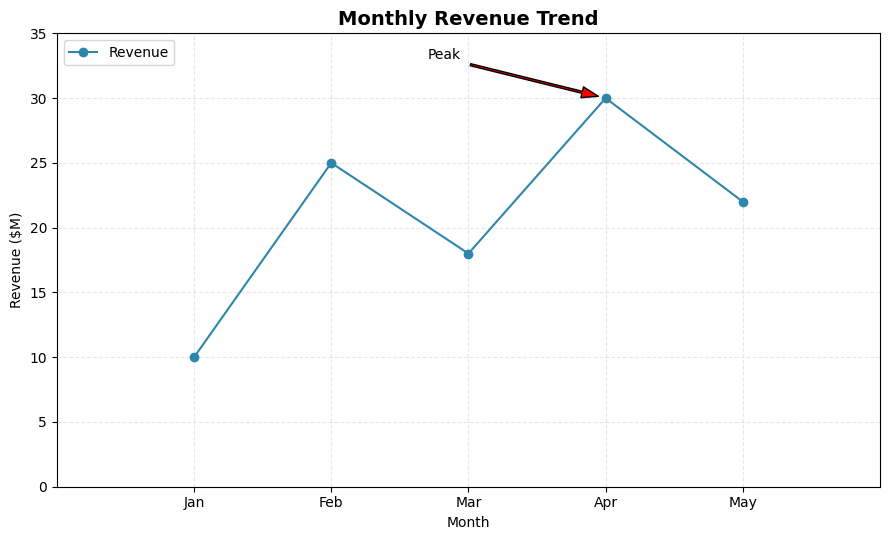

In [3]:
# Example 1: all 10 settings applied to one chart
# 예제 1: 10가지 설정을 모두 적용한 차트

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5.5))                                    # 6. figsize

ax.plot([1, 2, 3, 4, 5], [10, 25, 18, 30, 22],
        label="Revenue", color='#2E86AB', marker='o')

ax.set_title("Monthly Revenue Trend", fontsize=14, fontweight='bold')       # 1. title
ax.set_xlabel("Month")                                                      # 2. xlabel
ax.set_ylabel("Revenue ($M)")                                               # 3. ylabel
ax.legend(loc='upper left')                                                 # 4. legend
ax.grid(True, alpha=0.3, linestyle='--')                                    # 5. grid
ax.set_xlim(0, 6)                                                           # 7. xlim
ax.set_ylim(0, 35)                                                          # 7. ylim
ax.set_xticks([1, 2, 3, 4, 5])                                              # 8. xticks
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May'])                     # 8. xticklabels
ax.annotate('Peak', xy=(4, 30), xytext=(2.7, 33),                           # 9. annotate
            arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8))

plt.tight_layout()                                                          # 10. tight_layout
plt.show()

## Example 2: 4 Ways to Specify Color · 예제 2: 색상 지정 4가지 방법

| Method / 방법 | Example / 예시 | Notes / 특징 |
|---|---|---|
| ① Named color | `color='skyblue'` | ~150 built-in Matplotlib color names, most intuitive / Matplotlib에 등록된 약 150개 색상 이름, 가장 직관적 |
| ② Hex code | `color='#FF5733'` | Copy directly from any web/design tool / 웹·디자인 툴에서 그대로 가져올 수 있는 16진수 코드 |
| ③ RGB tuple | `color=(0.2, 0.4, 0.6)` | 3 floats between 0 and 1 (R, G, B) / 0~1 사이의 실수 3개 (R, G, B) |
| ④ Colormap | `cmap='viridis'` | Auto-assigns color by value, for continuous data / 값 크기에 따라 자동으로 색을 배정 (연속형 데이터용) |

⚠️ A very common mistake: RGB tuples must be in the 0-1 range, **not** 0-255. `(255, 87, 51)` raises a `ValueError`; you need `(255/255, 87/255, 51/255)` instead. This becomes Common Mistake #2 below.

⚠️ 자주 하는 실수: RGB tuple은 0~255가 아니라 반드시 0~1 범위여야 합니다. `(255, 87, 51)`을 그대로 넣으면 `ValueError`가 발생하며, `(255/255, 87/255, 51/255)`처럼 255로 나눠서 전달해야 합니다. 아래 자주 하는 실수 2번에서 다시 다룹니다.

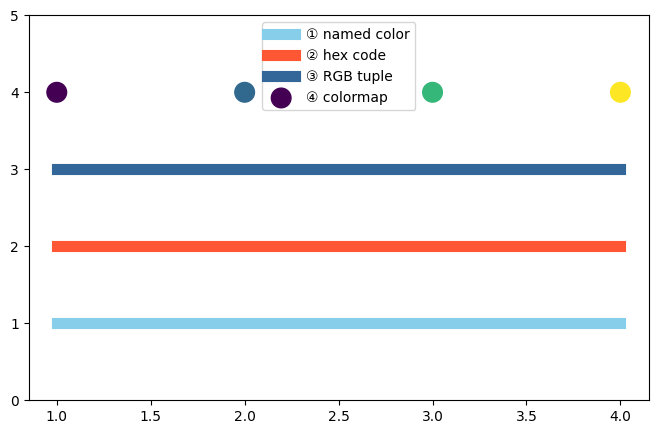

In [4]:
# Example 2: the 4 color methods side by side
# 예제 2: 4가지 색상 지정 방법을 나란히 비교

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
x = [1, 2, 3, 4]

ax.plot(x, [1, 1, 1, 1], color='skyblue', linewidth=8, label='① named color')
ax.plot(x, [2, 2, 2, 2], color='#FF5733', linewidth=8, label='② hex code')
ax.plot(x, [3, 3, 3, 3], color=(0.2, 0.4, 0.6), linewidth=8, label='③ RGB tuple')
ax.scatter(x, [4, 4, 4, 4], c=[10, 20, 30, 40], cmap='viridis', s=200, label='④ colormap')

ax.legend()
ax.set_ylim(0, 5)
plt.show()

## Example 3: Korean Font Setup · 예제 3: 한글 폰트 설정

Matplotlib's default font doesn't support Korean — without setup, Korean text renders as broken boxes (□□□). The fix is telling Matplotlib which Korean font your OS already has installed, and it must happen **before** you draw anything.

Matplotlib의 기본 폰트는 한글을 지원하지 않습니다 — 설정하지 않으면 한글 텍스트가 네모(□□□)로 깨져서 나옵니다. 해결책은 OS에 이미 설치된 한글 폰트를 Matplotlib에 알려주는 것이며, 반드시 그리기 **전에** 설정해야 합니다.

- macOS → `'AppleGothic'`
- Windows → `'Malgun Gothic'`
- Linux (Colab, Ubuntu, etc.) → `'NanumGothic'` (install first if missing: `!apt-get install -y fonts-nanum`)

Also always pair it with `plt.rcParams['axes.unicode_minus'] = False`, or the minus sign on negative axis values breaks even when the Korean text itself works fine.

`plt.rcParams['axes.unicode_minus'] = False`도 항상 함께 설정하세요 — 이게 없으면 한글은 잘 나와도 음수 부호만 네모로 깨집니다.

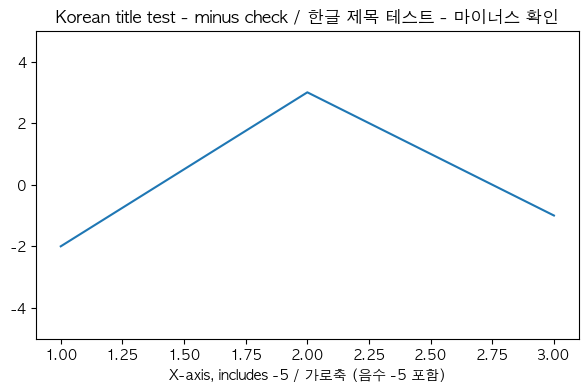

If the Korean text above shows as boxes, install a Korean font locally (e.g. Nanum Gothic).
위 그래프에서 한글이 네모로 보인다면, 로컬 환경에 한글 폰트(예: 나눔고딕)를 설치하세요.


In [ ]:
# Example 3: auto-detect the OS and set the right Korean font
# 예제 3: 운영체제를 자동 감지해서 올바른 한글 폰트 설정하기

import platform
import matplotlib.pyplot as plt

system = platform.system()
if system == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:                            # Linux (Colab, Ubuntu, etc.)
    plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False   # prevents the minus sign from breaking

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot([1, 2, 3], [-2, 3, -1])
ax.set_title("Korean title test - minus check / 한글 제목 테스트 - 마이너스 확인")
ax.set_xlabel("X-axis, includes -5 / 가로축 (음수 -5 포함)")
ax.set_ylim(-5, 5)
plt.show()

## Example 4: Saving Figures with plt.savefig() · 예제 4: plt.savefig()로 차트 저장하기

| Option / 옵션 | Meaning / 의미 | Practical tip / 실무 팁 |
|---|---|---|
| extension | PNG (raster, general docs/slides) vs SVG (vector, never blurs when zoomed) / PNG(래스터) vs SVG(벡터) | PNG for reports, SVG for print/logos / 보고서엔 PNG, 인쇄물·로고엔 SVG |
| dpi | Resolution (dots per inch) / 해상도 | 100 for screen, 300 for print (SVG ignores dpi) / 화면용 100, 인쇄용 300 |
| bbox_inches='tight' | Auto-crops excess whitespace / 여백을 자동으로 잘라내어 저장 | Without it, titles/labels are often cut off / 안 쓰면 제목·라벨이 잘려서 저장되는 경우가 많음 |

Saved 3 files: chart_web.png (dpi=100), chart_print.png (dpi=300), chart_vector.svg
3개 파일 저장됨: chart_web.png (dpi=100), chart_print.png (dpi=300), chart_vector.svg


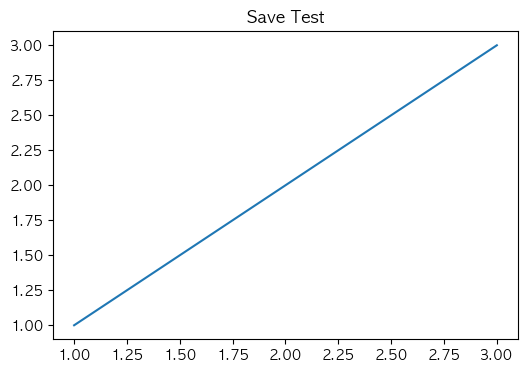

In [6]:
# Example 4: saving the same chart three different ways
# 예제 4: 같은 차트를 세 가지 방식으로 저장하기

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([1, 2, 3], [1, 2, 3])
ax.set_title("Save Test")

fig.savefig('chart_web.png', dpi=100, bbox_inches='tight')      # web / screen use
fig.savefig('chart_print.png', dpi=300, bbox_inches='tight')    # print / presentation
fig.savefig('chart_vector.svg', bbox_inches='tight')            # vector, lossless zoom

print("Saved 3 files: chart_web.png (dpi=100), chart_print.png (dpi=300), chart_vector.svg")
print("3개 파일 저장됨: chart_web.png (dpi=100), chart_print.png (dpi=300), chart_vector.svg")
plt.show()

## Example 5: Practice · 예제 5: 연습문제

**Part A** rebuilds a 1x2 line+bar layout — fill in a Figure size. **Part B** rebuilds a horizontal bar chart with an annotation — fill in a hex color. Both run without error either way; the real chart only appears once the blanks are filled in.

**Part A**는 1x2 line+bar 레이아웃을 다시 만듭니다 — Figure 크기를 채우세요. **Part B**는 annotate가 있는 가로 막대 차트를 다시 만듭니다 — hex 색상을 채우세요. 둘 다 어떤 상태든 에러 없이 실행되며, 빈칸을 채워야만 실제 차트가 나타납니다.

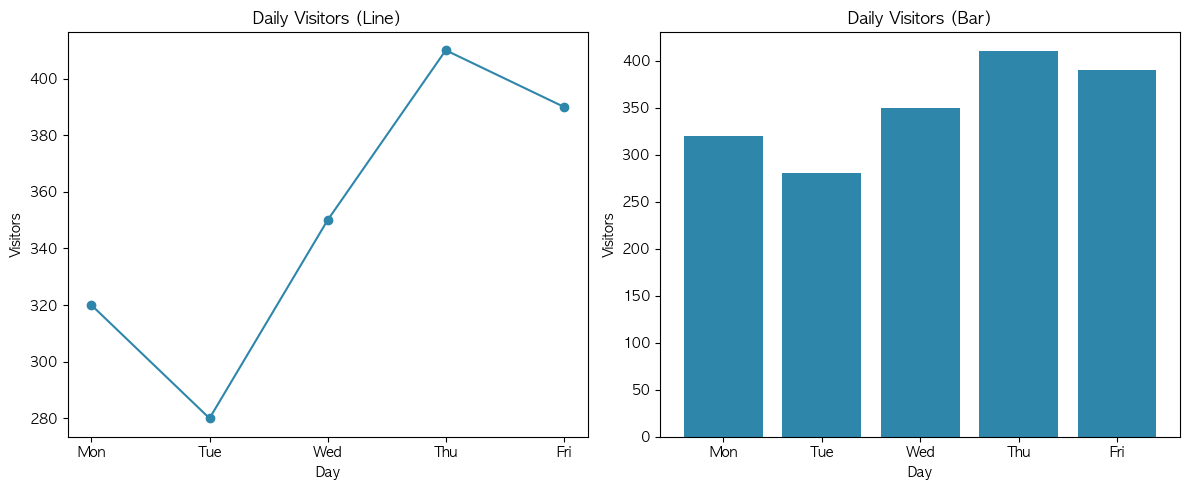

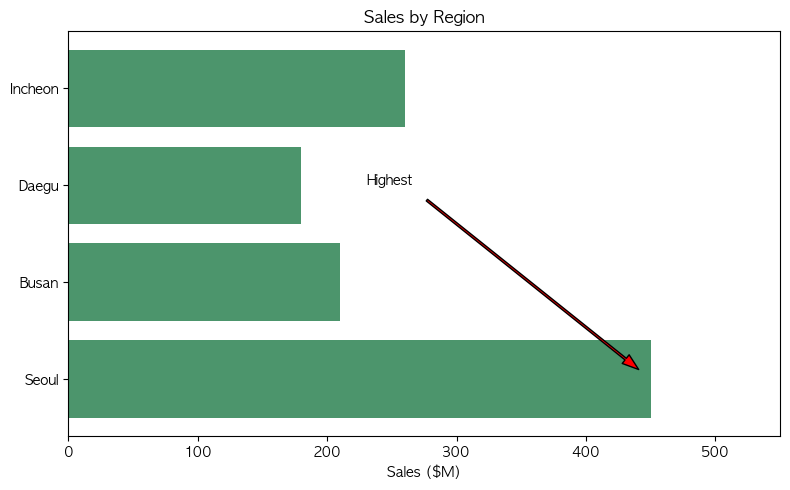

In [12]:
# Practice: fill in the blanks, then re-run this cell
# 연습문제: 빈칸을 채운 후 셀을 다시 실행하세요

import matplotlib.pyplot as plt

# ---- Part A: 1x2 subplot (Line + Bar) of daily visitors ----
# ---- Part A: 요일별 방문자 수를 1x2 서브플롯(Line + Bar)으로 ----
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
visitors = [320, 280, 350, 410, 390]

fig_width = 12     # TODO: a number, e.g. 12
fig_height = 5    # TODO: a number, e.g. 5

if fig_width == "________" or fig_height == "________":
    print("Part A: fill in fig_width and fig_height above, then re-run.")
    print("Part A: 위의 fig_width, fig_height를 채운 후 다시 실행하세요.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height))
    axes[0].plot(days, visitors, marker='o', color='#2E86AB')
    axes[0].set_title("Daily Visitors (Line)")
    axes[0].set_xlabel("Day")
    axes[0].set_ylabel("Visitors")
    axes[1].bar(days, visitors, color='#2E86AB')
    axes[1].set_title("Daily Visitors (Bar)")
    axes[1].set_xlabel("Day")
    axes[1].set_ylabel("Visitors")
    plt.tight_layout()
    plt.show()

# ---- Part B: horizontal bar with a hex color + annotate the highest region ----
# ---- Part B: hex 색상 가로 막대 + 최고 지역 annotate ----
regions = ['Seoul', 'Busan', 'Daegu', 'Incheon']
sales = [450, 210, 180, 260]

hex_color = "#4C956C"        # TODO: any valid hex color string, e.g. '#4C956C'
annotation_text = "Highest"  # TODO: a short label, e.g. 'Highest'

if hex_color == "________" or annotation_text == "________":
    print("Part B: fill in hex_color and annotation_text above, then re-run.")
    print("Part B: 위의 hex_color, annotation_text를 채운 후 다시 실행하세요.")
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(regions, sales, color=hex_color)
    ax.set_title("Sales by Region")
    ax.set_xlabel("Sales ($M)")
    ax.set_xlim(0, 550)
    ax.annotate(annotation_text, xy=(450, 'Seoul'), xytext=(230, 'Daegu'),
                arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8))
    plt.tight_layout()
    plt.show()

---
# ⚠️ Common Mistakes · 자주 하는 실수

### Mistake 1: Confusing Axes with Axis · 실수 1: Axes와 Axis 혼동

Mixing up "Axes" (a plot area) and "Axis" (an x or y axis line) leads to confusing search results and mismatched code when you're looking things up.

"Axes"(그래프 영역)와 "Axis"(x축 또는 y축)를 혼동하면 코드를 검색하거나 질문할 때 엉뚱한 결과를 얻게 됩니다.

✅ **Fix:** Remember it as Axes = the plot area, Axis = the line itself; the diagram in the Concept section above is worth re-reading whenever you're unsure.   
✅ **해결:** Axes=그래프 영역, Axis=축(선) 그 자체로 구분해서 기억하세요. 헷갈릴 때마다 위 Concept 섹션의 다이어그램을 다시 보세요.

### Mistake 2: Passing 0-255 RGB values directly · 실수 2: RGB를 0~255로 그대로 입력

Design tools often give you colors as `(255, 87, 51)`. Passing that tuple straight into `color=` raises `ValueError: ... not a valid value for color`.

디자인 툴에서 색상을 `(255, 87, 51)`처럼 알려주는 경우가 많습니다. 그 tuple을 그대로 `color=`에 넣으면 `ValueError: ... not a valid value for color`가 발생합니다.

✅ **Fix:** Divide every channel by 255 first — `(255/255, 87/255, 51/255)` — since Matplotlib always expects floats between 0 and 1.   
✅ **해결:** 각 채널을 255로 나눈 값을 사용하세요 — `(255/255, 87/255, 51/255)`. Matplotlib은 항상 0~1 사이의 실수를 기대합니다.

### Mistake 3: Forgetting axes.unicode_minus · 실수 3: axes.unicode_minus 누락

Setting a Korean font alone isn't enough — without also setting `plt.rcParams['axes.unicode_minus'] = False`, Korean text renders fine but the minus sign on negative values breaks into a box.

한글 폰트만 설정하는 것으로는 충분하지 않습니다 — `plt.rcParams['axes.unicode_minus'] = False`를 함께 설정하지 않으면 한글은 잘 나와도 음수 부호만 네모로 깨집니다.

✅ **Fix:** Always set the two rcParams lines together, as a pair, every time.  
✅ **해결:** 두 rcParams 줄을 항상 짝으로 함께 설정하세요.

### Mistake 4: Setting rcParams after the chart is already drawn · 실수 4: 폰트 설정을 차트를 그린 후에 실행

`plt.rcParams` changes only affect elements drawn *after* the setting is applied — running it after `ax.plot()`/`ax.set_title()` leaves already-drawn text unaffected.

`plt.rcParams` 변경은 설정 이후에 그려지는 요소에만 적용됩니다 — `ax.plot()`/`ax.set_title()` 이후에 실행하면 이미 그려진 텍스트에는 적용되지 않습니다.

✅ **Fix:** Put the rcParams lines at the very top of the script, right after the `import` statements.  
✅ **해결:** rcParams 설정은 코드 최상단, `import` 직후에 배치하세요.

### Mistake 5: Forgetting bbox_inches='tight' · 실수 5: bbox_inches='tight' 누락

Saved images frequently crop off the title or axis labels at the edges when this is left out.

이 옵션을 빼먹으면 저장된 이미지에서 제목이나 축 라벨이 가장자리에서 잘리는 경우가 많습니다.

✅ **Fix:** Include `bbox_inches='tight'` in every `savefig()` call by default — it never hurts.  
✅ **해결:** `savefig()` 호출 시 `bbox_inches='tight'`를 항상 기본으로 포함하세요 — 손해 볼 일이 없습니다.

### Mistake 6: Using plt.savefig() with multiple figures · 실수 6: 여러 Figure 사용 시 plt.savefig() 사용

`plt.savefig()` (the pyplot-level function) always saves whichever Figure is currently "active." In a loop that creates several Figures, that's frequently not the one you meant to save.

`plt.savefig()`(pyplot 레벨 함수)는 항상 "현재 활성화된" Figure를 저장합니다. 여러 Figure를 만드는 반복문에서는 의도한 것과 다른 Figure가 저장되는 경우가 실무에서 자주 발생합니다.

✅ **Fix:** Call `.savefig()` directly on the specific Figure object instead — `fig.savefig(...)`.  
✅ **해결:** 특정 Figure 객체에 직접 `.savefig()`를 호출하세요 — `fig.savefig(...)`로 명시적으로 지정합니다.

---
# 💡 Tips · 팁
Useful tips or shortcuts · 유용한 팁과 지름길

- Set `plt.rcParams` (font, unicode_minus) immediately after your imports, before you draw anything — settings applied later won't retroactively fix already-drawn text.  
`plt.rcParams`(폰트, unicode_minus)는 import 직후 아무것도 그리기 전에 설정하세요 — 나중에 설정하면 이미 그려진 텍스트에는 적용되지 않습니다.
- When saving inside a loop over multiple figures, always call `fig.savefig()` on the specific Figure object, never the bare `plt.savefig()`.  
여러 figure를 반복문으로 저장할 때는 항상 특정 Figure 객체에 `fig.savefig()`를 호출하세요, `plt.savefig()`는 피하세요.
- Default to `bbox_inches='tight'` on every save — it costs nothing and prevents cropped titles and labels.  
저장할 때는 항상 `bbox_inches='tight'`를 기본으로 쓰세요 — 손해가 없고 제목·라벨 잘림을 방지합니다.
- Keep two go-to dpi values in mind: 100 for screen sharing, 300 for print or presentation slides.  
화면 공유용은 dpi 100, 인쇄나 발표 자료용은 dpi 300, 이 두 값을 기본으로 기억해두세요.
- Type the Korean font name exactly as one word — `'NanumGothic'`, not `'Nanum Gothic'` — a stray space makes Matplotlib fail to recognize it.  
한글 폰트 이름은 붙여쓰기로 정확히 입력하세요 — `'Nanum Gothic'`이 아니라 `'NanumGothic'` — 띄어쓰기가 하나라도 있으면 Matplotlib이 인식하지 못합니다.
- If a font you just installed still won't render, it's often a stale font cache — add it directly with `fm.fontManager.addfont('경로.ttf')`, or clear the folder from `matplotlib.get_cachedir()` and restart the kernel.  
방금 설치한 폰트가 계속 적용되지 않는다면 폰트 캐시가 갱신되지 않은 경우가 많습니다 — `fm.fontManager.addfont('경로.ttf')`로 직접 추가하거나, `matplotlib.get_cachedir()` 경로의 캐시 폴더를 삭제하고 커널을 재시작하세요.

---
# 🔗 Related Concepts · 관련 개념

```
   Section 1: Visualization Foundations
   (chart selection framework, tool landscape)
                ↓
   Section 2: Matplotlib Basics (Figure & Axes)   ←  YOU ARE HERE / 지금 여기
   (the shared engine every chart type sits on top of)
                ↓
   Section 3: Line Chart   (first specific chart type)
                ↓
   Sections 4-8: Bar / Distribution / Relationship / Ratio / Composite charts
                ↓
   Section 9: Subplots & Dashboards   (these skills, scaled up with GridSpec)
```

*How is today's topic connected to other concepts?* · *오늘 배운 내용이 다른 개념과 어떻게 연결되는가?*

Nothing you learn here becomes obsolete — `fig, ax = plt.subplots()` becomes the standard first line of essentially every code cell from Section 3 onward, and every one of the 10 core settings from Example 1 (title, legend, grid, annotate, etc.) gets reused directly in every future chart type. Section 9 later revisits this exact same `plt.subplots()` idea with `GridSpec` and `subplot_mosaic`, letting you build uneven, dashboard-style layouts instead of only equal grids.

여기서 배운 내용은 어느 것도 쓸모없어지지 않습니다 — `fig, ax = plt.subplots()`는 섹션 3부터 사실상 모든 코드 셀의 표준 첫 줄이 되며, Example 1의 10가지 핵심 설정(title, legend, grid, annotate 등) 하나하나가 이후 모든 차트 유형에서 그대로 재사용됩니다. 섹션 9에서는 같은 `plt.subplots()` 아이디어를 `GridSpec`과 `subplot_mosaic`으로 확장해, 균등한 격자뿐 아니라 불균등한 대시보드 레이아웃까지 만들 수 있게 됩니다.

---
# 💼 Business Example · 비즈니스 예제
*How would a Business Analyst use this?* · *비즈니스 분석가는 이것을 어떻게 활용할까?*

**Scenario / 시나리오:**
It's the end of H1, and your manager wants a single-image dashboard for the leadership review: channel sales trend, this month's channel comparison, regional growth, and where online sales peaked — all in one 2x2 layout.

상반기가 끝났고, 매니저가 경영진 리뷰용으로 채널별 매출 추이, 이번 달 채널 비교, 지역별 성장률, 온라인 매출 최고점을 한 이미지에 담은 2x2 대시보드를 요청합니다.

**To-Do / 할 일:**
- [x] Set up the Korean font first, since all the data labels are in Korean  
데이터 라벨이 모두 한글이므로 한글 폰트부터 설정하기
- [x] Build a 2x2 dashboard combining a line chart, a bar chart with a colormap, a horizontal bar chart with conditional color, and an annotated peak  
line 차트, colormap 막대 차트, 조건부 색상 가로 막대, annotate로 강조한 최고점을 2x2로 결합하기
- [x] Save the finished dashboard with `fig.savefig()` and `bbox_inches='tight'`  
`fig.savefig()`와 `bbox_inches='tight'`로 완성된 대시보드 저장하기

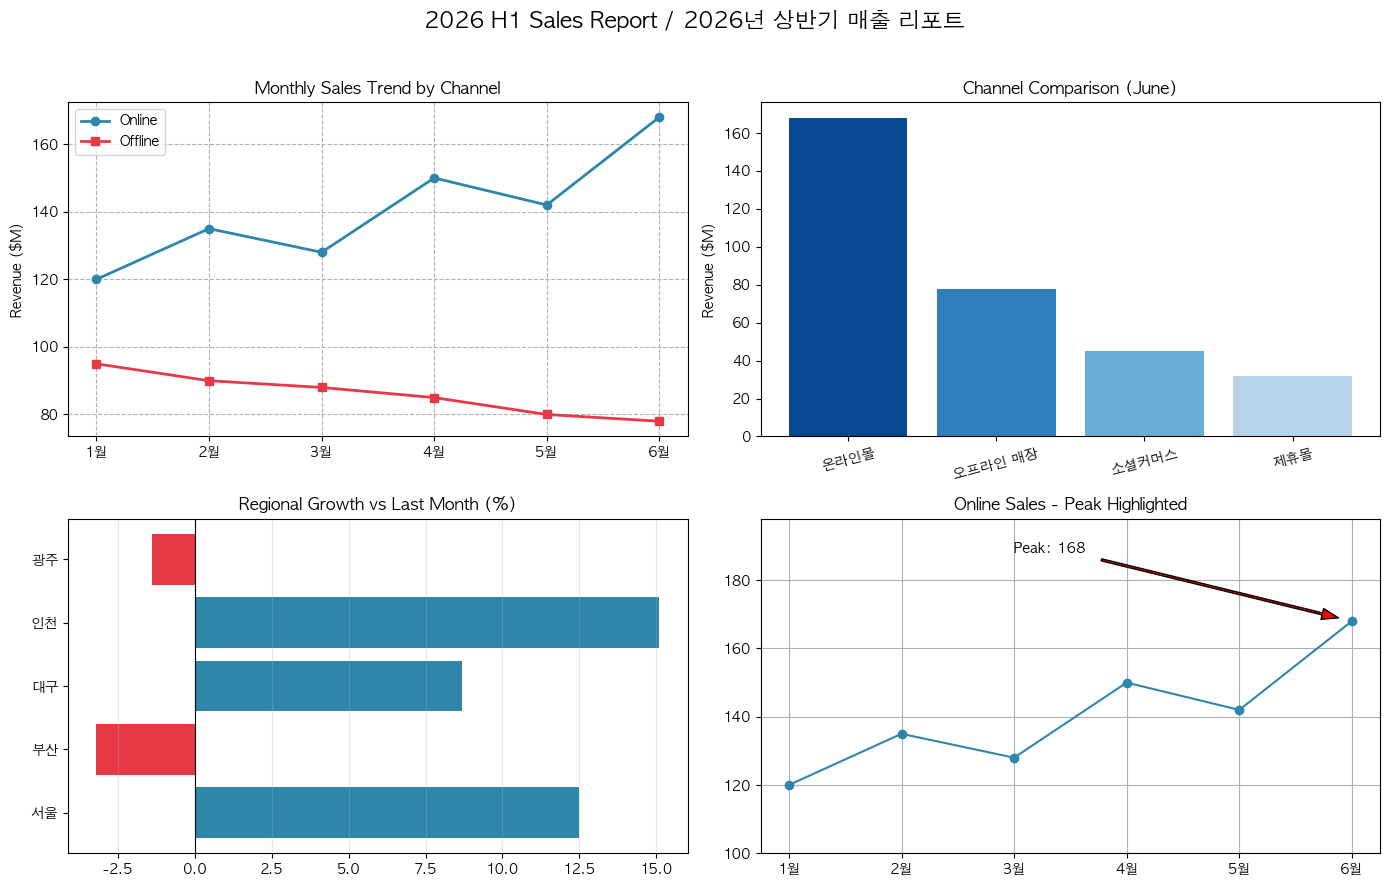

In [ ]:
# Business Example: 2026 H1 sales report dashboard
# 비즈니스 예제: 2026년 상반기 매출 리포트 대시보드

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'   # macOS: 'AppleGothic', Windows: 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# self-contained dataset / 자체 포함형 데이터셋
months = ['1월', '2월', '3월', '4월', '5월', '6월']
online_sales = [120, 135, 128, 150, 142, 168]
offline_sales = [95, 90, 88, 85, 80, 78]
channels = ['온라인몰', '오프라인 매장', '소셜커머스', '제휴몰']
channel_sales = [168, 78, 45, 32]
regions = ['서울', '부산', '대구', '인천', '광주']
region_growth = [12.5, -3.2, 8.7, 15.1, -1.4]

fig = plt.figure(figsize=(14, 9))
fig.suptitle('2026 H1 Sales Report / 2026년 상반기 매출 리포트', fontsize=16, fontweight='bold')

# (1) top-left: monthly trend by channel - Line
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(months, online_sales, marker='o', color='#2E86AB', linewidth=2, label='Online')
ax1.plot(months, offline_sales, marker='s', color='#E63946', linewidth=2, label='Offline')
ax1.set_title('Monthly Sales Trend by Channel')
ax1.set_ylabel('Revenue ($M)')
ax1.legend()
ax1.grid(True, alpha=1, linestyle='--')

# (2) top-right: channel comparison - Bar + colormap
ax2 = fig.add_subplot(2, 2, 2)
colors_bar = plt.cm.Blues([0.9, 0.7, 0.5, 0.3])
ax2.bar(channels, channel_sales, color=colors_bar)
ax2.set_title('Channel Comparison (June)')
ax2.set_ylabel('Revenue ($M)')
ax2.tick_params(axis='x', rotation=15)

# (3) bottom-left: regional growth - horizontal bar + conditional color
ax3 = fig.add_subplot(2, 2, 3)
bar_colors = ['#2E86AB' if v >= 0 else '#E63946' for v in region_growth]
ax3.barh(regions, region_growth, color=bar_colors)
ax3.set_title('Regional Growth vs Last Month (%)')
ax3.axvline(0, color='black', linewidth=0.8)
ax3.grid(True, alpha=0.3, axis='x')

# (4) bottom-right: online sales peak - annotate
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(months, online_sales, color='#2E86AB', marker='o')
ax4.set_title('Online Sales - Peak Highlighted')
ax4.set_ylim(min(online_sales) - 20, max(online_sales) + 30)
ax4.annotate(f'Peak: {max(online_sales)}',
             xy=(5, max(online_sales)), xytext=(2, max(online_sales) + 20),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10)
ax4.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# fig.savefig('h1_sales_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# print("Dashboard saved as h1_sales_dashboard.png")
# print("대시보드가 h1_sales_dashboard.png로 저장되었습니다")

---
# 📝 Summary · 요약
*Write today's concept in 3~5 sentences.* · *오늘 배운 개념을 3~5문장으로 정리하세요.*

A Figure is the whole canvas and an Axes is one plot area inside it — nearly every chart in Matplotlib starts with `fig, ax = plt.subplots()`, and passing `(nrows, ncols)` turns `ax` into an array you index to build multi-chart layouts. Ten settings (title, xlabel, ylabel, legend, grid, figsize, xlim/ylim, xticks, annotate, tight_layout) cover the vast majority of everyday polishing needs. Color can be specified as a named color, a hex code, an RGB tuple (0-1 range, not 0-255), or a colormap, and Korean text requires setting a Korean font plus `axes.unicode_minus` before any drawing happens. Finally, always save with `fig.savefig()` — not the bare `plt.savefig()` — and default to `bbox_inches='tight'` so nothing gets cropped.

Figure는 그림 전체를 담는 도화지이고 Axes는 그 안의 그래프 영역 하나입니다 — Matplotlib의 거의 모든 차트는 `fig, ax = plt.subplots()`로 시작하며, `(nrows, ncols)`를 넘기면 `ax`가 여러 차트 레이아웃을 만들기 위해 인덱싱하는 배열이 됩니다. 10가지 설정(title, xlabel, ylabel, legend, grid, figsize, xlim/ylim, xticks, annotate, tight_layout)이 일상적인 꾸미기 작업의 대부분을 커버합니다. 색상은 이름·hex 코드·RGB tuple(0~255가 아닌 0~1 범위)·colormap으로 지정할 수 있으며, 한글 텍스트는 그리기 전에 한글 폰트와 `axes.unicode_minus`를 함께 설정해야 합니다. 마지막으로, 저장은 항상 `plt.savefig()`가 아닌 `fig.savefig()`로 하고, 잘림을 방지하기 위해 `bbox_inches='tight'`를 기본으로 사용하세요.

---
# 📌 One Sentence Summary · 한 줄 요약
Today's topic in ONE sentence. · 오늘의 주제를 한 문장으로.

> Every Matplotlib chart starts life as `fig, ax = plt.subplots()`, and the handful of Axes settings you learn to apply to that one Axes today will be reused, unchanged, in every chart type for the rest of this course.

> 모든 Matplotlib 차트는 `fig, ax = plt.subplots()`에서 시작하며, 오늘 그 하나의 Axes에 적용하는 법을 배운 몇 가지 설정들은 이 강의의 남은 모든 차트 유형에서 그대로 재사용된다.

---
# ❓ Review Questions · 복습 문제

**Q1.** What is the difference between a Figure and an Axes, and how is "Axes" different from "Axis"?
Figure와 Axes의 차이는 무엇이며, "Axes"는 "Axis"와 어떻게 다른가?

**Q2.** If you call `fig, axes = plt.subplots(2, 2)`, what type of object is `axes`, and how would you access the top-right plot area?
`fig, axes = plt.subplots(2, 2)`를 호출하면 `axes`는 어떤 타입의 객체이며, 우상단 그래프 영역에는 어떻게 접근하는가?

**Q3.** Name the 10 core Axes settings covered in Example 1, and pick any two to explain what they do.
Example 1에서 다룬 10가지 핵심 Axes 설정의 이름을 말하고, 그중 2개를 골라 무엇을 하는지 설명하라.

**Q4.** Why does an RGB tuple like `(255, 87, 51)` raise a ValueError in Matplotlib, and how do you fix it?
`(255, 87, 51)` 같은 RGB tuple이 Matplotlib에서 왜 ValueError를 일으키며, 어떻게 고치는가?

**Q5.** Why should you use `fig.savefig()` instead of `plt.savefig()` when your script creates more than one Figure, and what does `bbox_inches='tight'` protect against?
스크립트가 여러 Figure를 생성할 때 `plt.savefig()` 대신 `fig.savefig()`를 써야 하는 이유는 무엇이며, `bbox_inches='tight'`는 무엇을 방지하는가?

---
*📅 Try answering these again in a few days.* · *📅 며칠 후에 다시 답해보세요.*